In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import roc_auc_score, accuracy_score, roc_curve, auc, confusion_matrix, precision_recall_curve
import matplotlib.pyplot as plt
import seaborn as sns

import ipywidgets as widgets
from IPython.display import display

In [ ]:
data = pd.read_csv('https://raw.githubusercontent.com/Sohi07/Heart-Disease-Prediction-Model-Python-and-ML-Internship/refs/heads/main/heart.csv')

In [ ]:
data['Sex'] = data['Sex'].map({'M': 1, 'F': 0})
data['ChestPainType'] = data['ChestPainType'].map({'ATA': 0, 'NAP': 1, 'ASY': 2, 'TA': 3})
data['RestingECG'] = data['RestingECG'].map({'Normal': 0, 'ST': 1, 'LVH': 2})
data['ExerciseAngina'] = data['ExerciseAngina'].map({'N': 0, 'Y': 1})
data['ST_Slope'] = data['ST_Slope'].map({'Up': 0, 'Flat': 1, 'Down': 2})

In [ ]:
X = data.drop('HeartDisease', axis=1)
y = data['HeartDisease']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:

models = {
    'Logistic Regression': LogisticRegression(),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Naive Bayes': GaussianNB()
}

results = {}
model_objects = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]

    accuracy = accuracy_score(y_test, y_pred)
    auc_score = roc_auc_score(y_test, y_pred_proba)

    results[name] = {'Accuracy': accuracy, 'AUC': auc_score}
    model_objects[name] = model

best_model_name = max(results, key=lambda x: (results[x]['Accuracy'], results[x]['AUC']))
best_model = model_objects[best_model_name]

print("Model Performance:")
for name, metrics in results.items():
    print(f"{name} - Accuracy: {metrics['Accuracy']:.2f}, AUC: {metrics['AUC']:.2f}")

print(f"\n The best model is: {best_model_name}")


Model Performance:
Logistic Regression - Accuracy: 0.84, AUC: 0.89
Decision Tree - Accuracy: 0.81, AUC: 0.81
Random Forest - Accuracy: 0.87, AUC: 0.94
Naive Bayes - Accuracy: 0.84, AUC: 0.92

 The best model is: Random Forest


In [ ]:
def get_user_input():
    age = widgets.IntSlider(min=20, max=100, description='Age:')
    sex = widgets.Dropdown(options=[('Male', 1), ('Female', 0)], description='Sex:')
    chest_pain_type = widgets.Dropdown(options=[('ATA', 0), ('NAP', 1), ('ASY', 2), ('TA', 3)], description='Chest Pain:')
    resting_bp = widgets.IntSlider(min=90, max=200, description='RestingBP:')
    cholesterol = widgets.IntSlider(min=100, max=600, description='Cholesterol:')
    fasting_bs = widgets.Dropdown(options=[('No', 0), ('Yes', 1)], description='FastingBS > 120:')
    resting_ecg = widgets.Dropdown(options=[('Normal', 0), ('ST', 1), ('LVH', 2)], description='Resting ECG:')
    max_hr = widgets.IntSlider(min=60, max=202, description='MaxHR:')
    exercise_angina = widgets.Dropdown(options=[('No', 0), ('Yes', 1)], description='Ex. Angina:')
    oldpeak = widgets.FloatSlider(min= -2.6, max=6.2, step=0.1, description='Oldpeak:')
    st_slope = widgets.Dropdown(options=[('Up', 0), ('Flat', 1), ('Down', 2)], description='ST Slope:')


    ui = widgets.VBox([age, sex, chest_pain_type, resting_bp, cholesterol, fasting_bs, resting_ecg, max_hr, exercise_angina, oldpeak, st_slope])
    display(ui)

    return ui, age, sex, chest_pain_type, resting_bp, cholesterol, fasting_bs, resting_ecg, max_hr, exercise_angina, oldpeak, st_slope

ui, age, sex, chest_pain_type, resting_bp, cholesterol, fasting_bs, resting_ecg, max_hr, exercise_angina, oldpeak, st_slope = get_user_input()

In [ ]:
def make_prediction():
    new_data = pd.DataFrame({
        'Age': [age.value],
        'Sex': [sex.value],
        'ChestPainType': [chest_pain_type.value],
        'RestingBP': [resting_bp.value],
        'Cholesterol': [cholesterol.value],
        'FastingBS': [fasting_bs.value],
        'RestingECG': [resting_ecg.value],
        'MaxHR': [max_hr.value],
        'ExerciseAngina': [exercise_angina.value],
        'Oldpeak': [oldpeak.value],
        'ST_Slope': [st_slope.value]
    })

    new_data_scaled = scaler.transform(new_data)
    prediction = best_model.predict(new_data_scaled)
    prediction_proba = best_model.predict_proba(new_data_scaled)[:, 1]

    if prediction[0] == 1:
        print("The model predicts that the person has heart disease.")
    else:
        print("The model predicts that the person does not have heart disease.")

    print(f"Probability of having heart disease: {prediction_proba[0]:.2f}")

predict_btn = widgets.Button(description="Predict")
predict_btn.on_click(lambda x: make_prediction())
display(predict_btn)

Button(description='Predict', style=ButtonStyle())

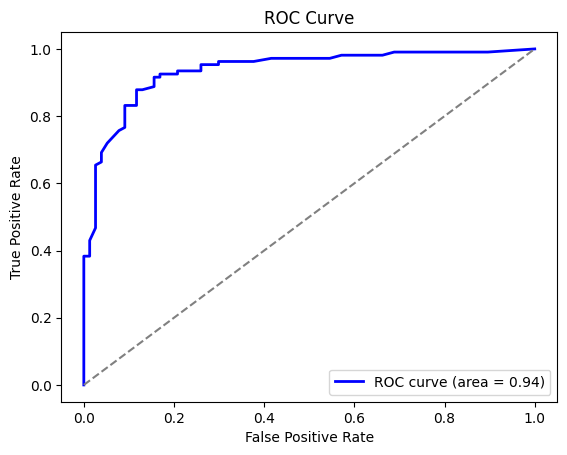

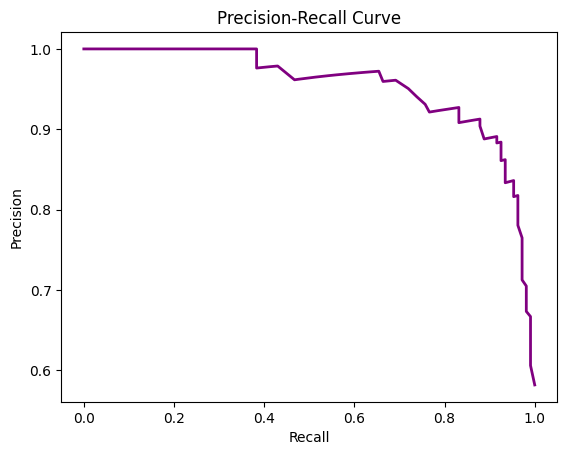

In [ ]:
fpr, tpr, _ = roc_curve(y_test, best_model.predict_proba(X_test)[:, 1])
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.show()

precision, recall, _ = precision_recall_curve(y_test, best_model.predict_proba(X_test)[:, 1])
plt.figure()
plt.plot(recall, precision, color='purple', lw=2)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.show()

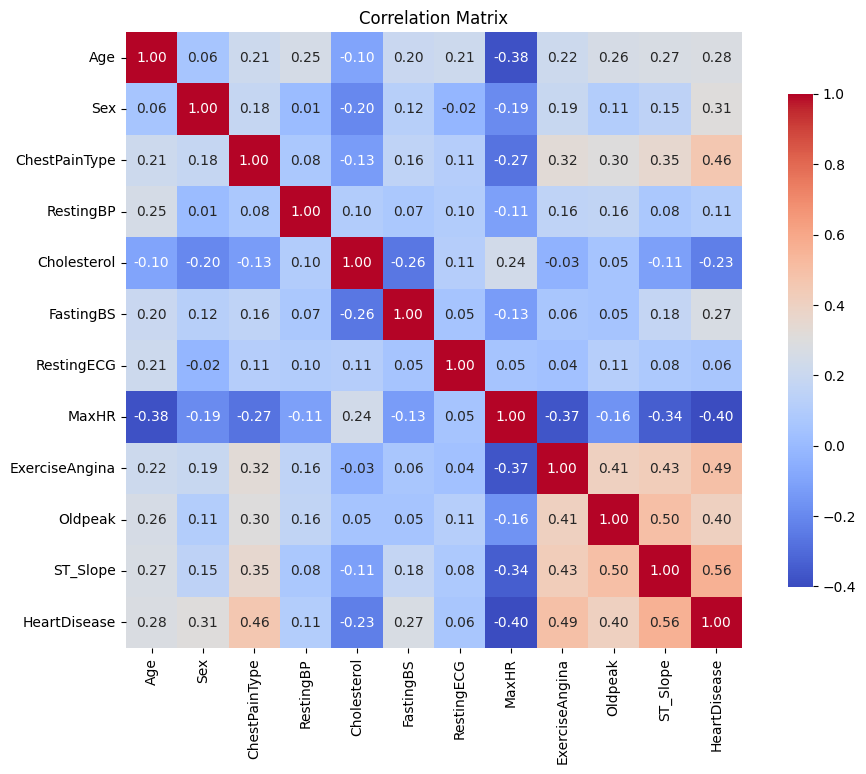

In [ ]:
plt.figure(figsize=(12, 8))
sns.heatmap(data.corr(), annot=True, fmt=".2f", cmap='coolwarm', square=True, cbar_kws={"shrink": .8})
plt.title('Correlation Matrix')
plt.show()



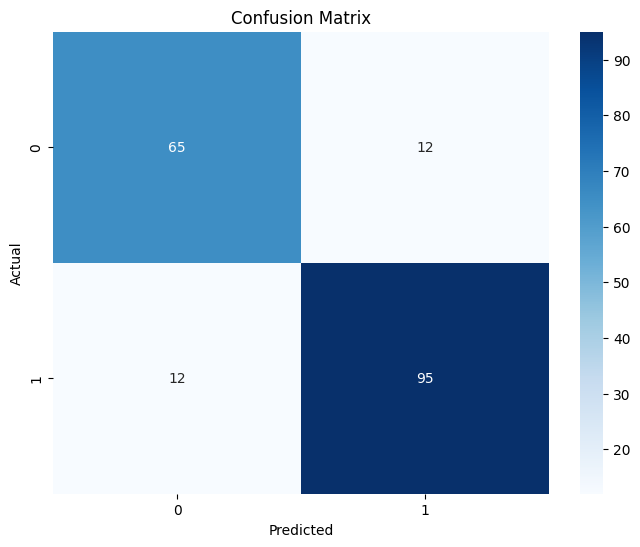

In [ ]:
cm = confusion_matrix(y_test, best_model.predict(X_test))
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

/tmp/ipython-input-65-1113813852.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')


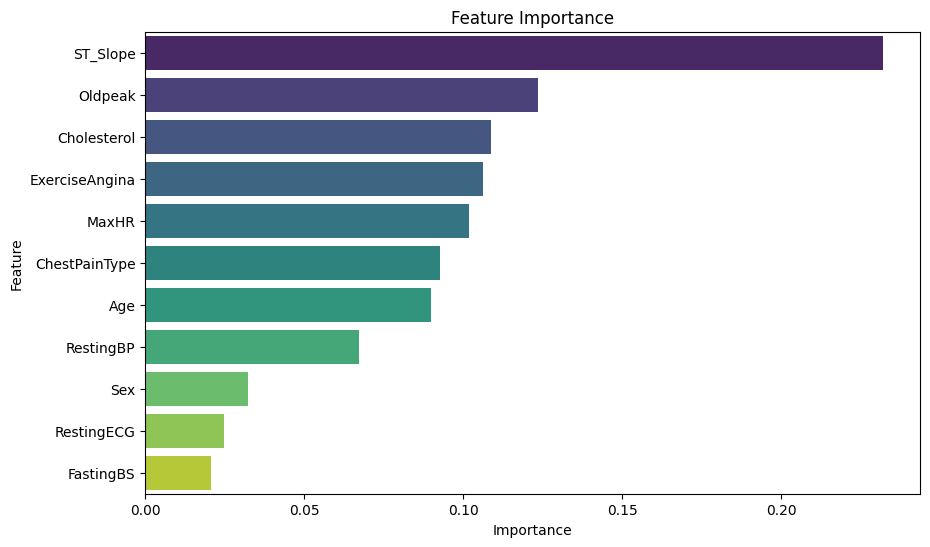

In [ ]:
if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
    features = X.columns
    feature_importance_df = pd.DataFrame({'Feature': features, 'Importance': importances})
    feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

    plt.figure(figsize=(10, 6))
    sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
    plt.title('Feature Importance')
    plt.show()